# Load Example Covariance Tensor

In this workbook we demonstrate some of the rudimentary IO functions for ```mmode_tools``` in particular the covariance tensor ```hdf5``` file format, and how to load and access the files.

In [1]:
from mmode_tools.plots import plot_baseline_fringes
from mmode_tools.io import get_config_directory
from mmode_tools.io import read_LST_VisCube
from mmode_tools.examples import load_example_interferometer
import mmode_tools
import os
import matplotlib.pyplot as plt


/Users/coo426/Documents/mmode-tools/.mmode_tools/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Loading the Interferometer Object

Here we demonstrate the interferometer object. This is simply a class that contains information about the lat, lon, and topographic positions of the antennas. These are used to compute the baseline $(u,v,w)$ values, which in turn are used to compute the beam fringe coefficients. In this package we provide an example $32$ element interferometer with a maximum baseline length of $35$m.

There are two ways to load in this interferometer. The first is by passing the ```N32_config.toml``` file through the ```make_radio_arra()``` function which returns the interferometer object. The second method is to use the ```load_example_interferometer``` function. Both load the same example. The first method is the general approach.

In [ ]:
from mmode_tools.interferometers import make_radio_array

interferometerPath = get_config_directory(pathName='interferometerPath')
interferometerFileName = 'N32_config.toml'


interferometer = make_radio_array(interferometerPath / interferometerFileName)

interferometer = load_example_interferometer()


TypeError: unsupported operand type(s) for +: 'PosixPath' and 'str'

Example plots that can be produced from the array. 

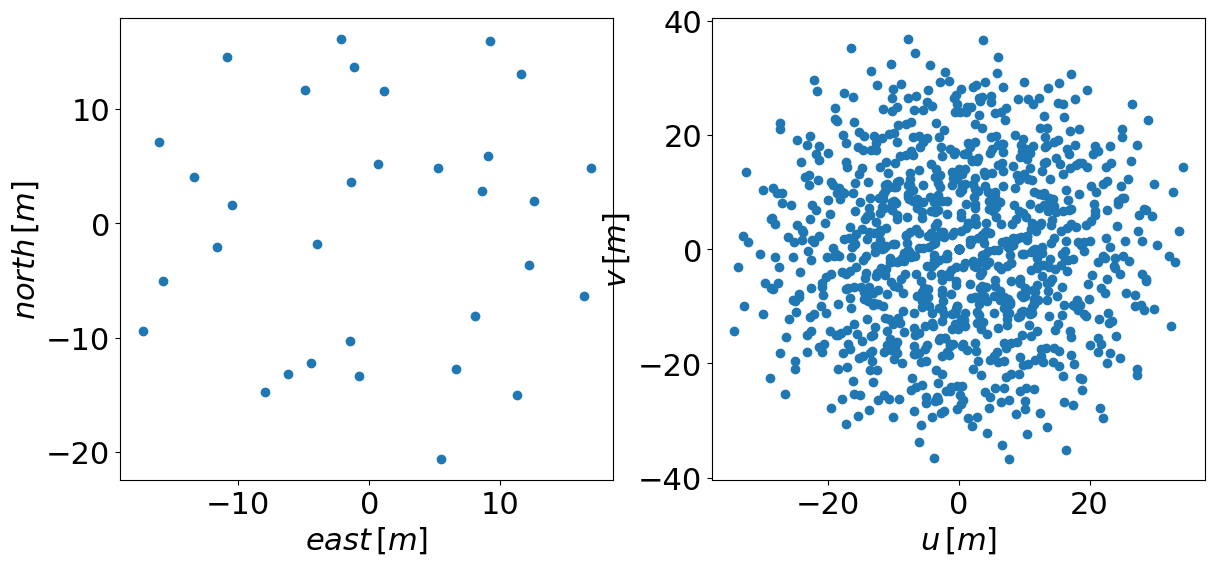

In [ ]:

fig,axs = plt.subplots(1,2,figsize=(14,6))

interferometer.plot_arr_layout(figaxs=(fig,axs[0]))
interferometer.plot_uv_dist(figaxs=(fig,axs[1]))

The function ```make_radio_array()``` has a lot of flexibility, alternatively a text file or even an array of east,north and height locations can be provided. The best practice is to have a configuration file, one can be created from an interferometer object with the method ```make_config_file``` and saved by default to the ```interferometerPath``` in the users home directory. 

## Loading the Example Covariance Tensor Files

Next we load in the example sky model covariance tensors, and demonstrate how to plot the fringes. This utilises the function ```read_LST_VisCube()``` which returns the lst time vector, and the covariance tensor for a given instrumental pol, which has a shape $(N_t,N_\mathrm{ant},N_\mathrm{ant})$. Each time slice is a correlation matrix, where each entry is a visibility and the diagonal terms are the autocorrelations. 

In [ ]:

covTensorPath = get_config_directory(pathName='covTensorPath')


haslamCovTensorFilePath = covTensorPath / "haslam_covtensor_N32_150MHz.h5"
pointSrcCovTensorFilePath = covTensorPath / "point_source_covtensor_N32_150MHz.h5"

if not os.path.exists(haslamCovTensorFilePath):
    mmode_tools.examples.make_haslam_covtensor()

if not os.path.exists(pointSrcCovTensorFilePath):
    mmode_tools.examples.make_point_covtensor()


lstVec,haslamCovTensor = read_LST_VisCube(haslamCovTensorFilePath,verbose=True)
lstVec,pointSrcCovTensor = read_LST_VisCube(pointSrcCovTensorFilePath,
                                            verbose=True)

<KeysViewHDF5 ['data', 'flags']>
<KeysViewHDF5 ['covtxx', 'covtxy', 'covtyx', 'covtyy', 'lst', 'tGPS']>
Loading xx instrumental polarisation.
Applying antenna and baseline flags...
Flags applied...
LST vector size/shape = (520,)
Visibility cube shape = (520, 32, 32)
Nant = 32
<KeysViewHDF5 ['data', 'flags']>
<KeysViewHDF5 ['covtxx', 'covtxy', 'covtyx', 'covtyy', 'lst', 'tGPS']>
Loading xx instrumental polarisation.
Applying antenna and baseline flags...
Flags applied...
LST vector size/shape = (520,)
Visibility cube shape = (520, 32, 32)
Nant = 32


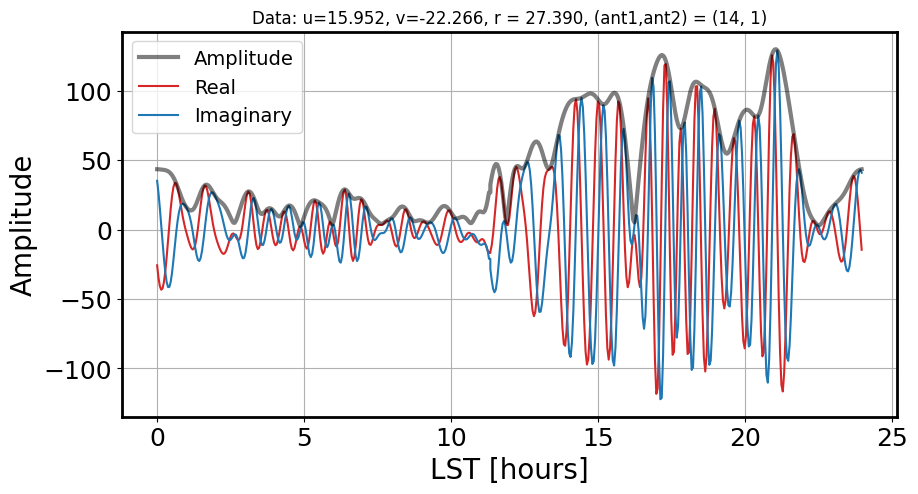

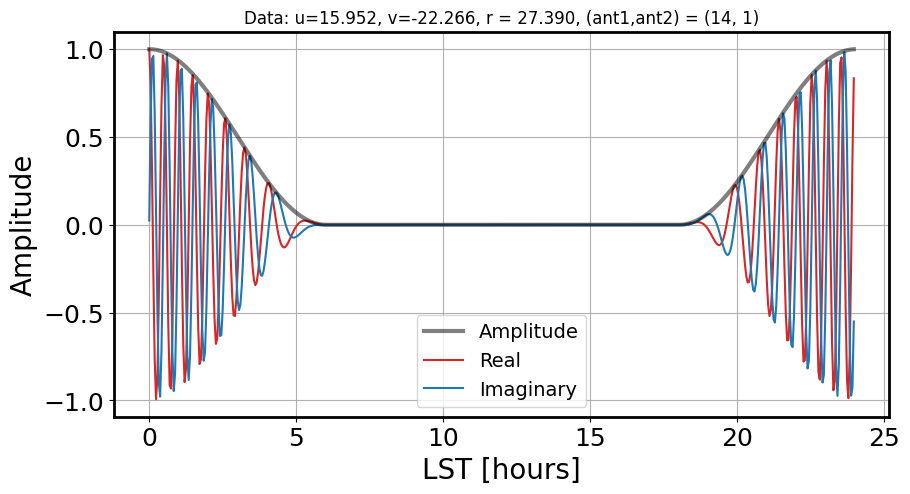

In [ ]:

plot_baseline_fringes(lstVec,haslamCovTensor,(14,1),interferometer)
plot_baseline_fringes(lstVec,pointSrcCovTensor,(14,1),interferometer)